## Librairies and functions

In [3]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Tortues\acoustic_classifier_seaturtles\src


In [4]:
from model import Model

In [5]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import torch
import gc

In [6]:
from sklearn.metrics import confusion_matrix,f1_score
import torch
import numpy as np
import pandas as pd
import os

In [7]:
def load_dataset(species_folder, species, dataset_type="train") -> tuple:
        """Loads the dataset from the save path"""
        # Load X dataset         
        with open(Path(species_folder, "Datasets", species + "_X_" + dataset_type + ".pkl"), "rb") as f:
            X = pickle.load(f)
        
        #load Y
        with open(Path(species_folder, "Datasets", species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
                Y = pickle.load(f)   
        
        return X, Y



## Parameters

In [8]:
selected_species = "gibbon" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())

Loaded settings for: gibbon
{'sample_rate': 9600, 'lowpass_cutoff': 2000, 'downsample_rate': 4800, 'nyquist_rate': 2400, 'segment_duration': 4, 'nb_negative_class': 10, 'annotation_extension': '.svl', 'audio_extension': '.wav', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1000, 'f_max': 2000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Gibbon'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'gibbon', 'negative_class': 'no-gibbon'}


In [9]:
config.data.species_folder=r"C:\Users\loren\Documents\Tortues\Dataset_Example"  #put your own path
save_path=Path(config.data.species_folder, "results")
save_path.mkdir(parents=True, exist_ok=True)

#### Architecture of the model

In [10]:
config.cnn_architecture.dict()

{'conv_layers': 1,
 'conv_filters': 8,
 'dropout_rate': 0.5,
 'conv_kernel': 8,
 'max_pooling_size': 4,
 'fc_units': 32,
 'fc_layers': 2,
 'conv_padding': None,
 'stride_maxpool': None,
 'num_classes': 2}

In [ ]:
#here you can play with CNN architecture
#Gibbon : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 8
config.cnn_architecture.dropout_rate = 0.5
config.cnn_architecture.fc_units = 32
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=128

## Training

In [13]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class)
X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val")

In [14]:
#print(f"Val set size: {len(X_val)}")
print(f"Train set size: {len(X_train)}")

Train set size: 2162


In [15]:
X_train.shape

(2162, 128, 76)

In [16]:


model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict(),
        )



In [17]:
model

BaseCNN(
  (conv_layers): Sequential(
    (conv0): Conv2d(1, 8, kernel_size=(8, 8), stride=(1, 1))
    (bn0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.5, inplace=False)
    (maxpool0): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (fc0): Linear(in_features=4080, out_features=32, bias=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.5, inplace=False)
    (fc1): Linear(in_features=32, out_features=32, bias=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.5, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
  (softmax): Softmax(dim=1)
)

In [18]:

model_name="baseline"
train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)



Training: 100%|██████████| 50/50 [00:19<00:00,  2.56epoch/s, lr=1.00e-03, train_loss=0.3224, val_loss=0.3355, best_val=0.3309]


#### plot val and train loss

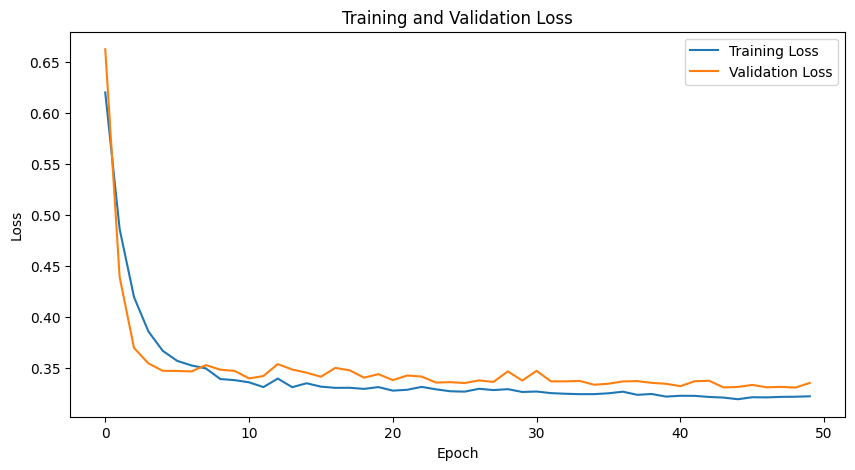

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot( val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [20]:
baseline_metric, baseline_metric_name = model.evaluate(
            X_val=X_train, Y_val=Y_train, print_report=True
        )

print(baseline_metric)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1080
           1       1.00      1.00      1.00      1082

    accuracy                           1.00      2162
   macro avg       1.00      1.00      1.00      2162
weighted avg       1.00      1.00      1.00      2162

[[1076    4]
 [   0 1082]]
0.9981549815498155


## Evaluation of the model

In [8]:
from evaluation import Evaluation
from model import Model
from settings import Config
from config_species import get_settings
import torch
import os

In [9]:
selected_species = "gibbon" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())


Loaded settings for: gibbon
{'sample_rate': 9600, 'lowpass_cutoff': 2000, 'downsample_rate': 4800, 'nyquist_rate': 2400, 'segment_duration': 4, 'nb_negative_class': 10, 'annotation_extension': '.svl', 'audio_extension': '.wav', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1000, 'f_max': 2000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Gibbon'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'gibbon', 'negative_class': 'no-gibbon'}


In [10]:
#load the model
config.data.species_folder=r"C:\Users\loren\Documents\Tortues\Dataset_Example"
save_path=Path(config.data.species_folder, "results")
model_name="baseline_cnn_state.pth"

model_path = os.path.join(save_path, model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model.load_cnn(model_path, device)


In [11]:
overlap=0.25
nb_to_group=2
threshold=0.8
step_size=1

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                step_size=step_size,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

In [12]:
evaluation.run(model, type="val", test_type="testing_dataset")

Data Loaded from:  C:\Users\loren\Documents\Tortues\Dataset_Example\Datasets
Evaluating...
f1 score : 0.9813486370157819
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       317
           1       0.99      0.97      0.98       353

    accuracy                           0.98       670
   macro avg       0.98      0.98      0.98       670
weighted avg       0.98      0.98      0.98       670

[[315   2]
 [ 11 342]]


(0.9813486370157819,
 array([[315,   2],
        [ 11, 342]]))

In [13]:
evaluation.run(model, type="test", test_type="testing_dataset")

Data Loaded from:  C:\Users\loren\Documents\Tortues\Dataset_Example\Datasets
Evaluating...
f1 score : 0.9819004524886877
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       630
           1       0.99      0.98      0.98       445

    accuracy                           0.99      1075
   macro avg       0.99      0.98      0.98      1075
weighted avg       0.99      0.99      0.99      1075

[[625   5]
 [ 11 434]]


(0.9819004524886877,
 array([[625,   5],
        [ 11, 434]]))

In [14]:
evaluation.run(model, type="test", test_type="entire_files", preprocessing_arg=True)

creating the folder
Processing file: ['HGSM3AB_0+1_20160304_060000']
2026-05-26 19:38:03.1 Processing file: ['HGSM3AB_0+1_20160304_060000'] 
No amplitudes to predict found on disk
Found file
2026-05-26 19:38:03.1 Load HGSM3AB_0+1_20160304_060000 data 


c:\Users\loren\anaconda3\envs\acoustic-ST\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtering...
Downsampling...
2026-05-26 19:38:11.5 Create list of spectrograms
Saved amplitudes to predict to disk:  C:\Users\loren\Documents\Tortues\Dataset_Example\amplitudes_to_predict_.wav\HGSM3AB_0+1_20160304_060000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['HGSM3AB_0+1_20160330_053900']
2026-05-26 19:38:28.7 Processing file: ['HGSM3AB_0+1_20160330_053900'] 
No amplitudes to predict found on disk
Found file
2026-05-26 19:38:28.7 Load HGSM3AB_0+1_20160330_053900 data 
Filtering...
Downsampling...
2026-05-26 19:38:41.6 Create list of spectrograms
Saved amplitudes to predict to disk:  C:\Users\loren\Documents\Tortues\Dataset_Example\amplitudes_to_predict_.wav\HGSM3AB_0+1_20160330_053900_amplitudes_to_predict.npy
Predicting...
Done
comparing prediction and annotation
Need to modify the annotations of the testing dataset to allow a correct evaluation of the model 
Found Prediction:  HGSM3AB_0+1_20160304_060000
-------------
HGSM3AB_0+1_20160304_060000
FP :  33
TP :

(np.float64(0.8142493638676844),
 array([[ 160,   64],
        [   9, 3416]]),
 87.65966010093689,
 np.float64(0.7142857142857143),
 np.float64(0.9467455621301775))